# Supplementary Embedding Plots

Two analysis sections:

1. **Supplementary Plots** — joint vs single-modality encoding similarity; normal vs full-run segment comparison
2. **Embedding Similarity Analysis** — RDMs, audio-video cosine similarity, and diagonal vs off-diagonal statistics across PE-AV model variants

**Environment:** `analysis`  
**Embedding path convention:** `{OUTPUT_BASE}/{model_name}/{bin_sec}s/{model_name}_{v,a,av}.npy`

In [9]:
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.signal import fftconvolve
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import gamma
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
OUTPUT_BASE = Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings")
TIMING_CSV  = Path("/home/amin/Research/Representation/Movie/data/movie_timing.csv")
FIGURE_DIR  = Path("/home/amin/Research/Representation/Movie/outputs/figures/supp_embedding")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BIN_SEC  = 5.0   # seconds per embedding bin
SKIP_SEC = 5.0
ALPHA    = 0.05  # significance threshold

# PE-AV model variants to compare
PEAV_MODELS = [
    "pe-av-small-16-frame",
    # "pe-av-small",
    # "pe-av-base",
    # "pe-av-base-16-frame",
    # "pe-av-large",
    # "pe-av-large-16-frame",
]
# ─────────────────────────────────────────────────────────────────────────────

timing_df = pd.read_csv(TIMING_CSV)
print(f"Timing: {len(timing_df)} video segments")
print(f"Figures → {FIGURE_DIR}")


Timing: 18 video segments
Figures → /home/amin/Research/Representation/Movie/outputs/figures/supp_embedding


## Helper Functions

In [11]:
def load_embeddings(model_name: str, modality: str, bin_sec: float, skip_sec: float) -> np.ndarray:
    path = OUTPUT_BASE / model_name / f"bin{int(bin_sec)}s_skip{int(skip_sec)}s" / f"{model_name}_{modality}.npy"
    if not path.exists():
        raise FileNotFoundError(f"Embedding not found: {path}")
    return np.load(path).astype(np.float32)


def compute_rdm(embeddings: np.ndarray, metric: str = "correlation") -> np.ndarray:
    return squareform(pdist(embeddings.astype(np.float64), metric=metric))


def spm_hrf(tr: float, oversampling: int = 16) -> np.ndarray:
    dt  = tr / oversampling
    t   = np.arange(0, 32 + dt, dt)
    hrf = gamma.pdf(t, 6) - gamma.pdf(t, 16) / 6.0
    hrf = hrf[::oversampling]
    hrf /= hrf.sum()
    return hrf


def compute_av_similarity(audio: np.ndarray, video: np.ndarray) -> np.ndarray:
    return cosine_similarity(audio.astype(np.float64), video.astype(np.float64))


def compute_diag_stats(sim: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    diag     = np.diag(sim)
    mask     = ~np.eye(sim.shape[0], dtype=bool)
    off_mean = np.array([sim[i, mask[i]].mean() for i in range(sim.shape[0])])
    off_se   = np.array([stats.sem(sim[i, mask[i]])  for i in range(sim.shape[0])])
    return diag, off_mean, off_se


def find_significant_segments(sim: np.ndarray, alpha: float = 0.05) -> List[int]:
    sig = []
    for i in range(sim.shape[0]):
        off_vals = np.concatenate([sim[i, :i], sim[i, i + 1:]])
        _, p = stats.ttest_1samp(off_vals, sim[i, i], alternative="less")
        if p < alpha and sim[i, i] > off_vals.mean():
            sig.append(i)
    return sig


def _safe_fname(title: str) -> str:
    return title.replace(':', '').replace('/', '-').replace(' ', '_')


def plot_heatmap(matrix: np.ndarray, title: str,
                 xlabel: str = "Segment", ylabel: str = "Segment",
                 cmap: str = "coolwarm", label: str = "Value") -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, origin="upper", cmap=cmap,
                   vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f'{_safe_fname(title)}.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_rdm(rdm: np.ndarray, title: str) -> None:
    plot_heatmap(rdm, title, cmap="viridis", label="Dissimilarity (1 − r)")


def plot_diag_stats(diag, off_mean, off_se, sig_indices, title, alpha, save=True) -> None:
    x = np.arange(len(diag))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, diag, label="Diagonal (matched A/V)", linewidth=1.5)
    ax.plot(x, off_mean, label="Off-diagonal mean", linewidth=1.5, color="C1")
    ax.fill_between(x, off_mean - off_se, off_mean + off_se,
                    color="C1", alpha=0.3, label="Off-diagonal ±1 SE")
    if sig_indices:
        ax.scatter(sig_indices, diag[sig_indices], marker="*",
                   color="red", s=150, zorder=3, label=f"Significant (p < {alpha})")
    ax.set_xlabel("Segment index", fontsize=11)
    ax.set_ylabel("Cosine similarity", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / f'{_safe_fname(title)}.png', dpi=300, bbox_inches='tight')
    plt.show()


print("Helpers defined.")


Helpers defined.


## Supplementary Plots

Compare **joint** vs **single-modality** PE-AV encodings, and **normal** (chunked segments) vs **full-run** embeddings.

## Embedding Similarity Analysis

For each PE-AV variant, compute:
- Audio-video cosine similarity matrix
- Audio, video, and joint RDMs
- Diagonal vs off-diagonal statistics (matched vs unmatched segment pairs)


pe-av-small-16-frame
  audio (626, 1024)  video (626, 1024)  av (626, 1024)


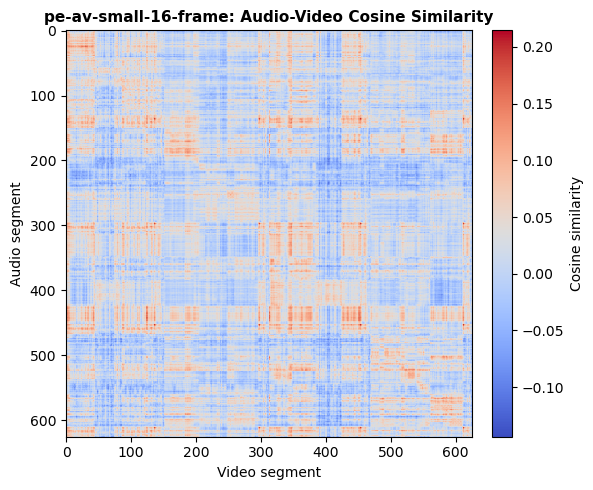

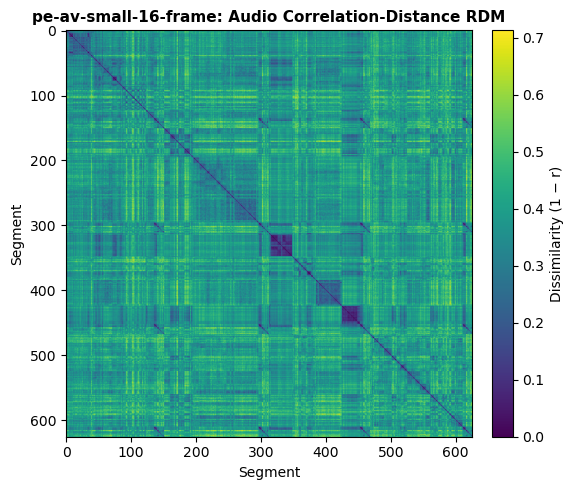

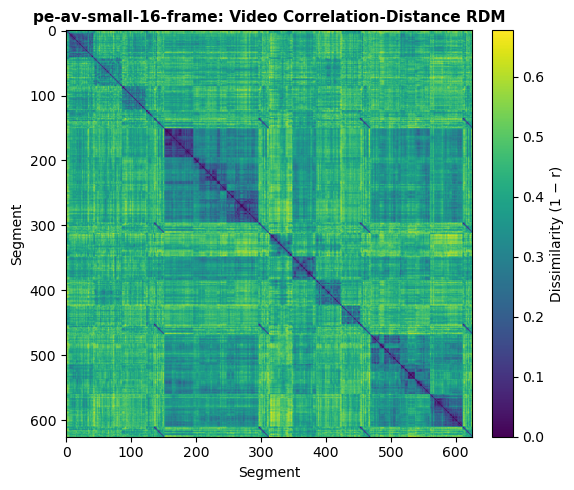

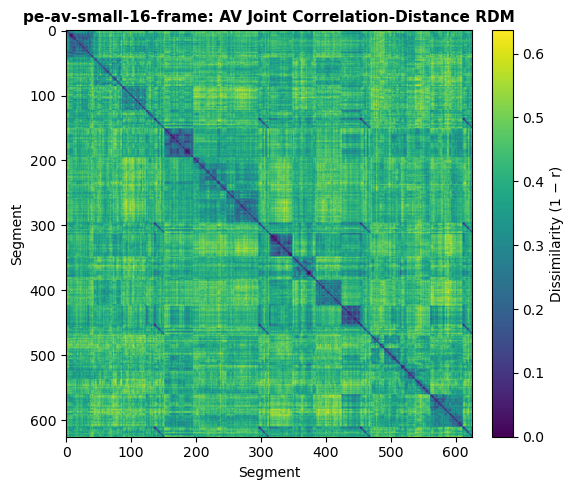

  Diagonal: mean=0.071  Off-diag: mean=0.017
  Significant (diag > off-diag, p < 0.05): 604 / 626


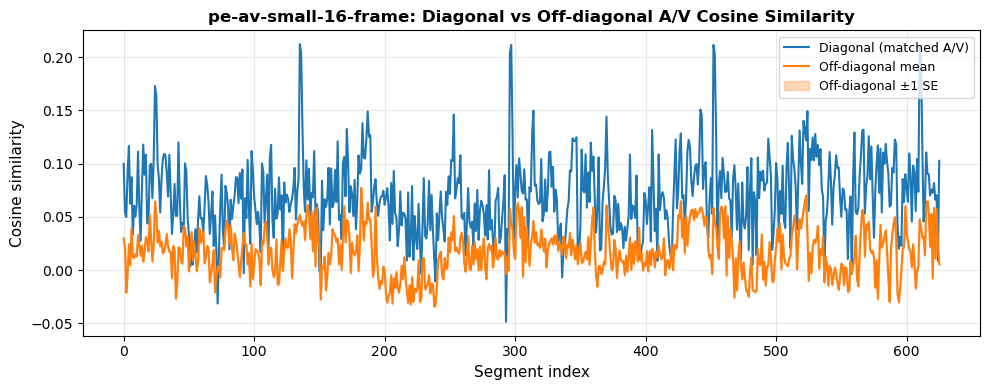

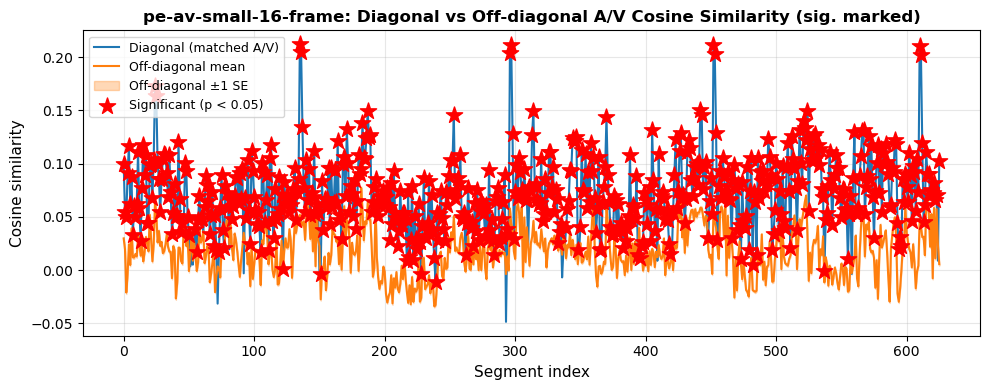


Done.


In [12]:
for model_name in PEAV_MODELS:
    emb_dir = OUTPUT_BASE / model_name / f"bin{int(BIN_SEC)}s_skip{int(SKIP_SEC)}s"
    if not emb_dir.exists():
        print(f"SKIP {model_name} — embeddings not found")
        continue

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    try:
        audio = load_embeddings(model_name, "a", BIN_SEC, SKIP_SEC)
        video = load_embeddings(model_name, "v", BIN_SEC, SKIP_SEC)
        av    = load_embeddings(model_name, "av", BIN_SEC, SKIP_SEC)
    except FileNotFoundError as e:
        print(f"  SKIP — {e}")
        continue

    print(f"  audio {audio.shape}  video {video.shape}  av {av.shape}")

    # Audio-video cosine similarity heatmap
    sim = compute_av_similarity(audio, video)
    plot_heatmap(sim, f"{model_name}: Audio-Video Cosine Similarity",
                 xlabel="Video segment", ylabel="Audio segment",
                 cmap="coolwarm", label="Cosine similarity")

    # Correlation-distance RDMs
    for mod_name, emb in [("Audio", audio), ("Video", video), ("AV Joint", av)]:
        rdm = compute_rdm(emb)
        plot_rdm(rdm, f"{model_name}: {mod_name} Correlation-Distance RDM")

    # Diagonal vs off-diagonal
    diag, off_mean, off_se = compute_diag_stats(sim)
    sig = find_significant_segments(sim, alpha=ALPHA)
    print(f"  Diagonal: mean={diag.mean():.3f}  Off-diag: mean={off_mean.mean():.3f}")
    print(f"  Significant (diag > off-diag, p < {ALPHA}): {len(sig)} / {len(diag)}")

    # saved version — no stars
    plot_diag_stats(diag, off_mean, off_se, [],
                    f"{model_name}: Diagonal vs Off-diagonal A/V Cosine Similarity", ALPHA,
                    save=True)
    # display-only version — with significance markers
    plot_diag_stats(diag, off_mean, off_se, sig,
                    f"{model_name}: Diagonal vs Off-diagonal A/V Cosine Similarity (sig. marked)", ALPHA,
                    save=False)

print("\nDone.")
